**Examinationsarbete i Deep Learning**

**Project $alpha$**

Målbild:

- Designa och träna Convolutional Neural Networks (CNNs) från grunden, för att klassificera bilder i CIFAR-10 datasetet.

Generella och specifika kraven för betygsgränser beskrivs längre ner.

---

**Dataset, CIFAR-10**

- **Antal bilder:** 60,000 (32x32 pixlar, färgbilder).
- **Klasser:** 10 klasser (t.ex. flygplan, bil, fågel, katt).
- **Uppdelning:**
  - Träning: 50,000 bilder.
  - Test: 10,000 bilder.

**Evalueringskrav**

Datasetet ska laddas in från PyTorchs `torchvision` bibliotek, och tillhörande testset ska användas för evaluering. 

---

**Project $alpha$**


Här ska ni designa och träna Convolutional Neural Networks (CNNs) från grunden, i syfte att klassificera bilder i CIFAR-10-datasetet. Modellerna som tränas för att uppnå kraven för **G** samt **VG** nedan får *ej* vara pretrained. 

**Krav för G:**
- Mellan **75-80% accuracy** på test-settet.
- Designa, träna och evaluera minst **tre olika CNN-arkitekturer**.
- Prestandan av varje färdigtränad modell ska vara tydlig, och även loss-kurvor ska plottas - följt av en kortfattad analys av dessa.
- I varje CNN-klass ska, i `forward`-metoden, **storleken på input och output för varje operation** skrivas ut som en kommentar.
- Gör dessutom en **kvalitativ analys** av dina modellers prestanda (vilka klasser presteras bra på, och vilka dåligt) - och varför, om möjligt.

**Krav för VG:**

- Uppnår kraven för **G**, och når **85%+ accuracy** på test-settet.
- Ni använder dessutom flertalet metoder under träningen som ni själva läst på och lärt er om, exempelvis via litteraturhänvisningen.
    - samtliga metoder, utöver de vi gått igenom i klassen, som ni väljer att använda ska ni i ett särskilt stycke i er notebook, förklara (så gott ni kan) 
    samt ge referenser till.
- Ni ska även att utföra en ordentlig error analysis, på er bäst presterade modell.

**Krav för Guldstjärna:**

- Uppnår kraven för **VG**, och når **90%+ accuracy** på test-settet.
- Hittar även en lämplig pretrained modell, anpassar den för datasetet samt uppnår **95%+** accuracy på test-settet. 





Var kreativa med era arkitekturer. Ni behöver exempelvis inte begränsa er till det 'normala' convolutional block som vi 
lärde oss under föreläsningarna (dvs conv layer + relu följt av pooling), utan det kan se annorlunda ut. Se litteraturhänvisningarna för inspiration från kända CNN-arkitekturer som ex. AlexNet, VGG, ResNet etc. 

Utöver det finns det andra knep man kan integrera in i sin CNN som empiriskt visat förbättra prestanda. Exempelvis:

- Batch Normalization
- Data Augmentation
- Alternativa Optimizers (ex Adam, RMSprop)
- Learning Rate Scheduling

Ni har friheten att själva söka information om dessa och hur de implementeras i PyTorch, för att sedan nyttja dem i ert projekt.

**Pre-trained models & Transfer Learning**

Kraven för **G** och **VG** utgår utifrån att man tränat modeller från grunden. För Guldstjärna ska ni som sagt även nyttja transfer learning med en redan färdigtränad modell. Det räcker med en sådan, om ni lyckas uppnå 95% accuracy på test-settet.

Det kan dock vara rätt beräkningstungt.

---

**Inlämning**



Ni lämnar in en notebook fil som innehåller allt arbete. Notebooken ska dessutom sparas med alla outputen kvarstående! 

Mao ska jag bara kunna bläddra igenom er notebook för att se allt arbete och alla output, utan att för den delen köra koden själv.

Spara notebook:en med namnet **{namn}\_{efternamn}\_{alpha}.ipynb**, och skicka därefter in via elevera-portalen.

---

**Literaturlista**

Följande research ger både en inblick i historiken av CNN-arkitekturers utveckling, och kan ge idéer om nyttiga idéer i era egna projekt:

* [__LeNet-5__](http://yann.lecun.com/exdb/lenet/). Grundläggande arbete som introducer konceptet med Convolutional Neural Networks.
* [__AlexNet__](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf). Vann ImageNet-tävlingen 2012, genom att bland annat introducera "ReLU".
* [__VGGNet__](https://arxiv.org/abs/1409.1556).
* [__GoogLeNet__](https://arxiv.org/abs/1409.4842). Introducerade "Inception"-modulen (aka "bottle-neck layer").
* [__ResNet__](http://openaccess.thecvf.com/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf). Introducerar "skip connections" som hjälper djupa nätverk att lära sig. 
* [__EfficientNet__](https://arxiv.org/abs/1905.11946)

Ni kan givetvis lära er mer om dessa koncept genom att söka efter alternativa källor också.





In [1]:
import torch
from torchvision import models
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import random_split

In [11]:


# 1. Definiera dina transforms
# Endast träning får RandomCrop och Flip
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Validering och Test ska vara identiska och "rena"
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# 2. Ladda rådata (utan transform än)
train_base = datasets.CIFAR10(root='./data', train=True, download=True)
test_base = datasets.CIFAR10(root='./data', train=False, download=True)

# 3. Skapa index för split
indices = list(range(50000))
# Vi tar de första 45k till träning och sista 5k till validering
train_idx, val_idx = indices[:45000], indices[45000:]

# 4. Använd ApplyTransform-klassen för att binda rätt transform till rätt subset
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices=None, transform=None):
        self.dataset = dataset
        self.indices = indices if indices is not None else range(len(dataset))
        self.transform = transform
    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.indices)

# Skapa de slutgiltiga objekten
train_data = ApplyTransform(train_base, train_idx, train_transform)
val_data = ApplyTransform(train_base, val_idx, test_transform)
test_data = ApplyTransform(test_base, None, test_transform)

# 5. DataLoaders (Jag rekommenderar batch_size 64 för stabilitet)
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    
    # Listor för att spara data till plotten
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        # --- TRÄNINGSFAS ---
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            scheduler.step()
            running_train_loss += loss.item()
        
        # --- VALIDERINGSFAS ---
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        # Beräkna snittvärden för epoken
        avg_train_loss = running_train_loss / len(train_loader)
        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * correct / total if total > 0 else 0

        # Spara värden i listorna
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch [{epoch+1}/{epochs}] - '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}% - '
              f'LR: {scheduler.get_last_lr()[0]:.6f}')
              
    print("Training completed!")
    # Returnera listorna så de kan användas utanför funktionen
    return train_losses, val_losses, val_accuracies

In [ ]:
class CNN1(nn.Module):
    def __init__(self):
        super(CNN1, self).__init__()
        
        # DEL 1: FEATURE EXTRACTION (Conv-lager)
        # Här letar modellen efter kanter, cirklar och objekt.
        self.features = nn.Sequential(
            # Första blocket
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32), # Batch Norm gör träningen stabilare
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32x32 blir 16x16
            
            # Andra blocket
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 16x16 blir 8x8
        )
        
        # DEL 2: CLASSIFIER (Linjära lager)
        # Här tar vi informationen från features och mappar till de 10 klasserna.
        self.classifier = nn.Sequential(
            nn.Flatten(), # Viktigt! Gör om 3D-data till en lång vektor
            nn.Linear(in_features=64 * 8 * 8, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.3), # Slumpar bort 50% av kopplingarna för att motverka overfitting
            nn.Linear(in_features=256, out_features=10) # Slutlager: 10 utgångar (en för varje klass i CIFAR10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [17]:
model1 = CNN1()
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.AdamW(model1.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer1, 
    max_lr=0.012, 
    steps_per_epoch=len(train_dataloader), 
    epochs=20, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Tränar Modell 1...")
train_loss, val_loss, val_acc = train_model(model1, train_dataloader, val_dataloader, criterion, optimizer1, scheduler, epochs=20)

Tränar Modell 1...
Epoch [1/20] - Train Loss: 1.6189, Val Loss: 1.3359, Val Acc: 51.60% - LR: 0.001252
Epoch [2/20] - Train Loss: 1.4784, Val Loss: 1.2533, Val Acc: 53.90% - LR: 0.003361
Epoch [3/20] - Train Loss: 1.3811, Val Loss: 1.2066, Val Acc: 57.52% - LR: 0.006242
Epoch [4/20] - Train Loss: 1.2880, Val Loss: 1.0841, Val Acc: 61.84% - LR: 0.009122
Epoch [5/20] - Train Loss: 1.2567, Val Loss: 1.1838, Val Acc: 59.88% - LR: 0.011230
Epoch [6/20] - Train Loss: 1.2269, Val Loss: 1.1000, Val Acc: 60.24% - LR: 0.012000
Epoch [7/20] - Train Loss: 1.1917, Val Loss: 1.0641, Val Acc: 62.72% - LR: 0.011849
Epoch [8/20] - Train Loss: 1.1707, Val Loss: 0.9785, Val Acc: 67.00% - LR: 0.011405
Epoch [9/20] - Train Loss: 1.1473, Val Loss: 0.9373, Val Acc: 68.06% - LR: 0.010690
Epoch [10/20] - Train Loss: 1.0965, Val Loss: 0.9139, Val Acc: 68.62% - LR: 0.009739
Epoch [11/20] - Train Loss: 1.0630, Val Loss: 0.8399, Val Acc: 70.52% - LR: 0.008602
Epoch [12/20] - Train Loss: 1.0224, Val Loss: 0.8529, V

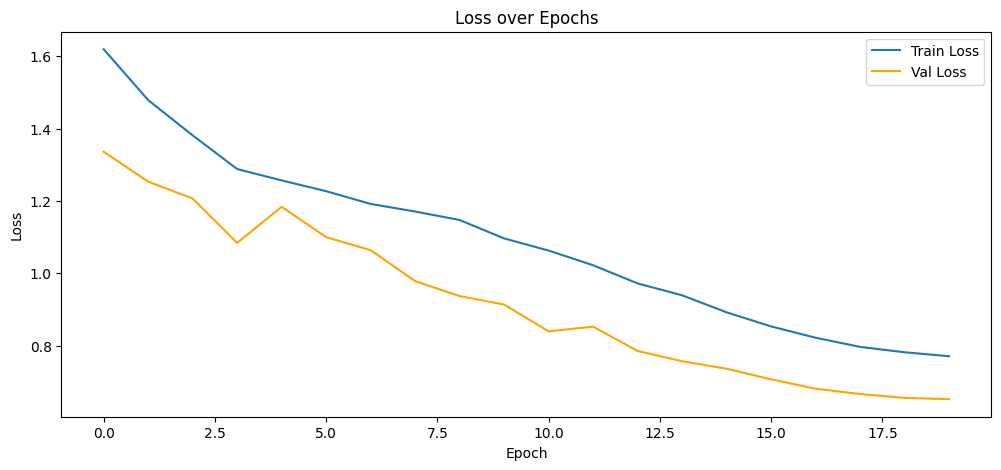

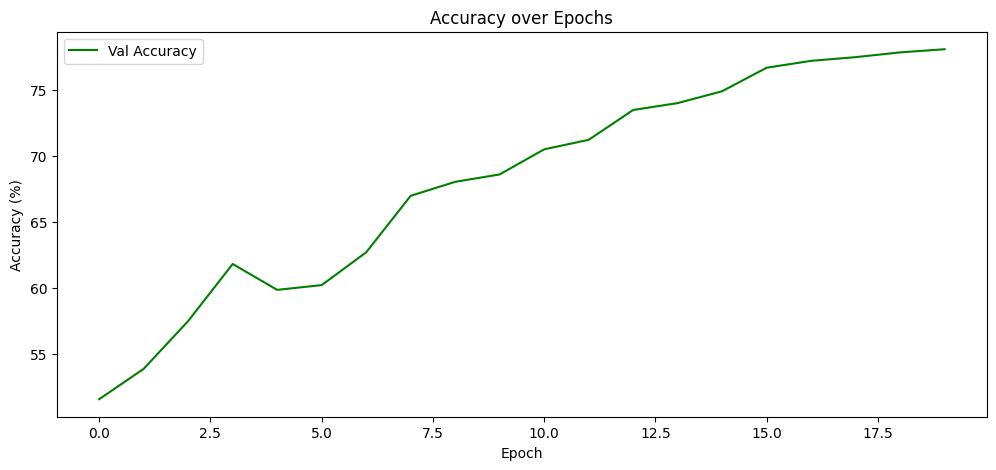

In [18]:

# 1. Plot Loss Curves (Använder din kodstil)
plt.figure(figsize=(12, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss', color='orange') # Jag ändrade 'test' till 'val' för tydlighet
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

In [ ]:
class CNN2(nn.Module):
    def __init__(self):
        super(CNN2, self).__init__()
        
        # DEL 1: FEATURE EXTRACTION (Conv-lager)
        # Här letar modellen efter kanter, cirklar och objekt.
        self.features = nn.Sequential(
            # Första blocket
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64), # Batch Norm gör träningen stabilare
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            
            # Andra blocket
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            
            #Tredje blocket
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
        )
        
        # CLASSIFIER (Linjära lager)
        self.classifier = nn.Sequential(
            nn.Flatten(), # Gör om 3D-data till en lång vektor
            nn.Linear(in_features=256 * 4 * 4, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=512, out_features=10) # Slutlager: 10 utgångar (en för varje klass i CIFAR10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [22]:
model2 = CNN2()
criterion = nn.CrossEntropyLoss()
optimizer2 = optim.AdamW(model2.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer2, 
    max_lr=0.012, 
    steps_per_epoch=len(train_dataloader), 
    epochs=20, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Tränar Modell 2...")
train_loss2, val_loss2, val_acc2 = train_model(model2, train_dataloader, val_dataloader, criterion, optimizer2, scheduler, epochs=20)

Tränar Modell 2...
Epoch [1/20] - Train Loss: 1.6155, Val Loss: 1.3313, Val Acc: 51.26% - LR: 0.001252
Epoch [2/20] - Train Loss: 1.2990, Val Loss: 1.1305, Val Acc: 59.70% - LR: 0.003361
Epoch [3/20] - Train Loss: 1.1409, Val Loss: 1.3058, Val Acc: 58.88% - LR: 0.006242
Epoch [4/20] - Train Loss: 1.0319, Val Loss: 1.3581, Val Acc: 60.28% - LR: 0.009122
Epoch [5/20] - Train Loss: 0.9954, Val Loss: 0.9759, Val Acc: 69.24% - LR: 0.011230
Epoch [6/20] - Train Loss: 0.9547, Val Loss: 0.9008, Val Acc: 72.12% - LR: 0.012000
Epoch [7/20] - Train Loss: 0.9032, Val Loss: 0.7598, Val Acc: 76.04% - LR: 0.011849
Epoch [8/20] - Train Loss: 0.8580, Val Loss: 0.7762, Val Acc: 74.64% - LR: 0.011405
Epoch [9/20] - Train Loss: 0.8047, Val Loss: 0.6473, Val Acc: 78.64% - LR: 0.010690
Epoch [10/20] - Train Loss: 0.7643, Val Loss: 0.6072, Val Acc: 80.76% - LR: 0.009739
Epoch [11/20] - Train Loss: 0.7100, Val Loss: 0.6252, Val Acc: 79.52% - LR: 0.008602
Epoch [12/20] - Train Loss: 0.6573, Val Loss: 0.6474, V

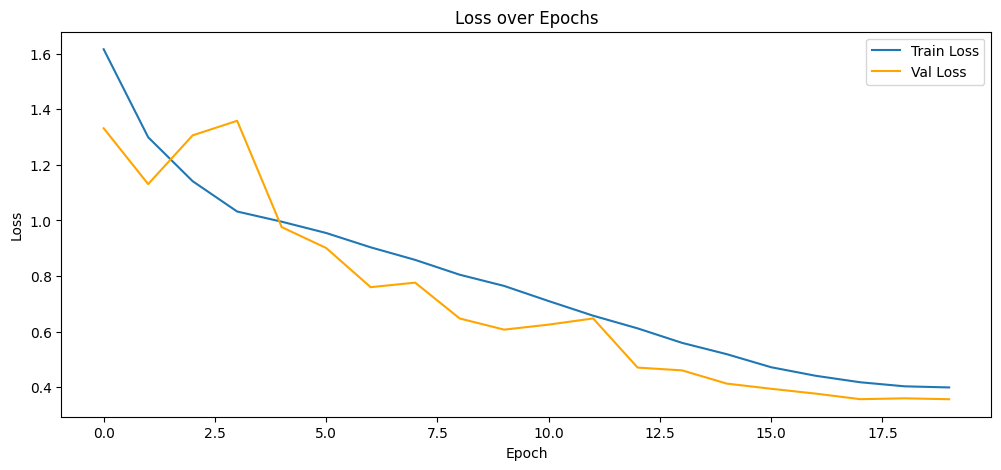

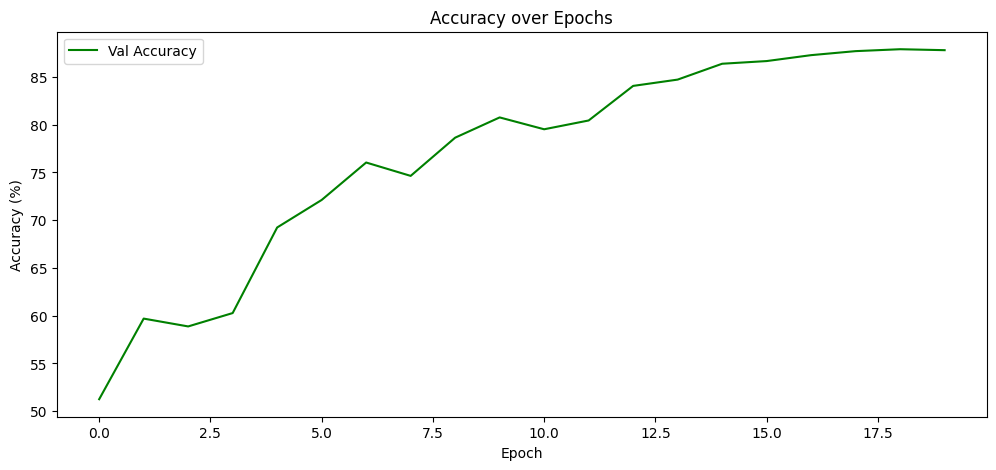

In [23]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss2, label='Train Loss')
plt.plot(val_loss2, label='Val Loss', color='orange') # Jag ändrade 'test' till 'val' för tydlighet
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc2, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

In [32]:
class CNN3(nn.Module):
    def __init__(self):
        super(CNN3, self).__init__()
        
        # DEL 1: FEATURE EXTRACTION (Conv-lager)
        # Här letar modellen efter kanter, cirklar och objekt.
        self.features = nn.Sequential(
            # Första blocket
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64), # Batch Norm gör träningen stabilare
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            
            # Andra blocket
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            
            #Tredje blocket
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3),

            #Fjärde blocket
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        
        # CLASSIFIER (Linjära lager)
        self.classifier = nn.Sequential(
            nn.Flatten(), # Gör om 3D-data till en lång vektor
            nn.Linear(in_features=512, out_features= 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(in_features=512, out_features=10) # Slutlager: 10 utgångar (en för varje klass i CIFAR10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [37]:
model3 = CNN3()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer3 = optim.AdamW(model3.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer3, 
    max_lr=0.005, 
    steps_per_epoch=len(train_dataloader), 
    epochs=30, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Tränar Modell 3...")
train_loss3, val_loss3, val_acc3 = train_model(model3, train_dataloader, val_dataloader, criterion, optimizer3, scheduler, epochs=30)

Tränar Modell 3...
Epoch [1/30] - Train Loss: 1.6563, Val Loss: 1.5202, Val Acc: 56.52% - LR: 0.000345
Epoch [2/30] - Train Loss: 1.3797, Val Loss: 1.3911, Val Acc: 61.88% - LR: 0.000762
Epoch [3/30] - Train Loss: 1.2642, Val Loss: 1.3569, Val Acc: 64.80% - LR: 0.001400
Epoch [4/30] - Train Loss: 1.1965, Val Loss: 1.1477, Val Acc: 72.64% - LR: 0.002184
Epoch [5/30] - Train Loss: 1.1413, Val Loss: 1.1643, Val Acc: 73.04% - LR: 0.003017
Epoch [6/30] - Train Loss: 1.0963, Val Loss: 1.0569, Val Acc: 77.20% - LR: 0.003801
Epoch [7/30] - Train Loss: 1.0501, Val Loss: 1.0693, Val Acc: 75.88% - LR: 0.004439
Epoch [8/30] - Train Loss: 1.0138, Val Loss: 1.0483, Val Acc: 78.14% - LR: 0.004856
Epoch [9/30] - Train Loss: 0.9877, Val Loss: 0.9735, Val Acc: 80.10% - LR: 0.005000
Epoch [10/30] - Train Loss: 0.9530, Val Loss: 0.8850, Val Acc: 83.78% - LR: 0.004972
Epoch [11/30] - Train Loss: 0.9294, Val Loss: 0.8686, Val Acc: 85.06% - LR: 0.004889
Epoch [12/30] - Train Loss: 0.9050, Val Loss: 0.8443, V

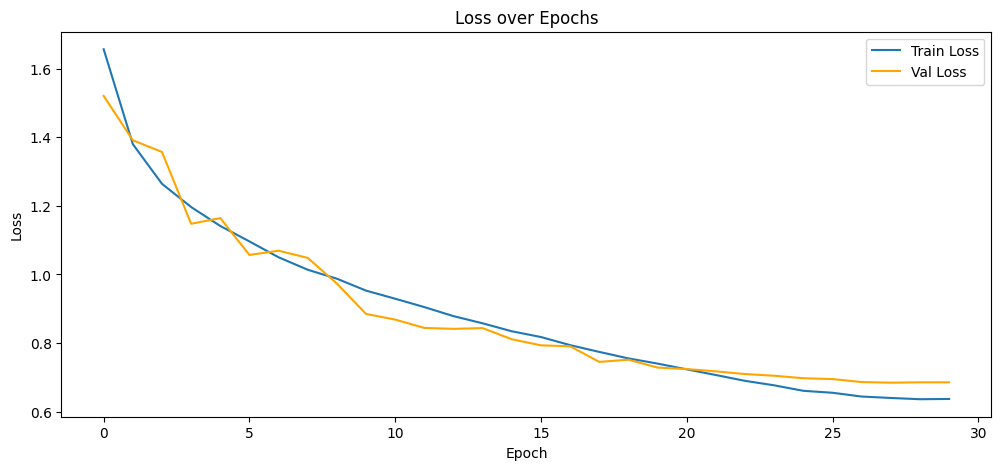

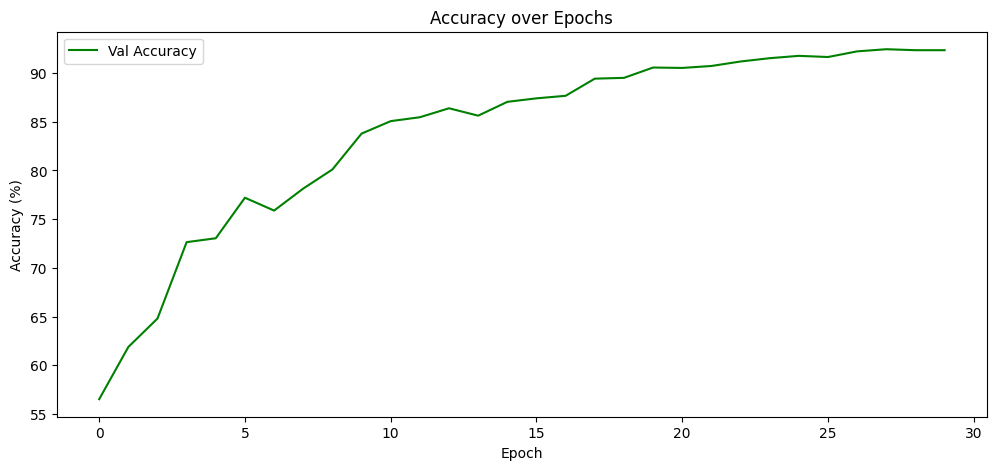

In [38]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss3, label='Train Loss')
plt.plot(val_loss3, label='Val Loss', color='orange') # Jag ändrade 'test' till 'val' för tydlighet
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc3, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

In [39]:
def evaluate_model(model, test_loader):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()  # Viktigt! Stänger av Dropout och sätter BatchNorm i valideringsläge
    
    correct = 0
    total = 0
    
    with torch.no_grad(): # Inga gradienter behövs vid evaluering (sparar minne)
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

In [40]:
# Kör evalueringen på din bästa modell
print("Evaluerar Modell 1 på testsetet...")
test_acc1 = evaluate_model(model1, test_dataloader)

print("Evaluerar Modell 2 på testsetet...")
test_acc2 = evaluate_model(model2, test_dataloader)

print("Evaluerar Modell 3 på testsetet...")
test_acc3 = evaluate_model(model3, test_dataloader)

Evaluerar Modell 1 på testsetet...
Test Accuracy: 77.04%
Evaluerar Modell 2 på testsetet...
Test Accuracy: 87.22%
Evaluerar Modell 3 på testsetet...
Test Accuracy: 91.73%


In [41]:
# Lista för att hålla reda på test-accuracy
test_accuracies = []

print("Evaluerar alla modeller på testsetet...")
test_accuracies.append(evaluate_model(model1, test_dataloader))
test_accuracies.append(evaluate_model(model2, test_dataloader))
test_accuracies.append(evaluate_model(model3, test_dataloader))

Evaluerar alla modeller på testsetet...
Test Accuracy: 77.04%
Test Accuracy: 87.22%
Test Accuracy: 91.73%


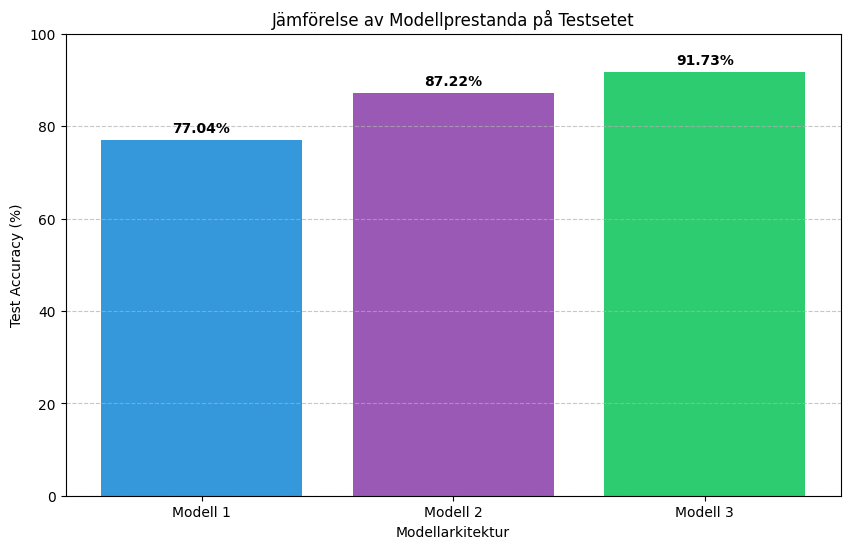

In [42]:
def plot_model_comparison(test_accs):
    models = ['Modell 1', 'Modell 2', 'Modell 3']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, test_accs, color=['#3498db', '#9b59b6', '#2ecc71'])
    
    plt.xlabel('Modellarkitektur')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Jämförelse av Modellprestanda på Testsetet')
    plt.ylim(0, 100) # Så man ser hela skalan upp till 100%
    
    # Lägg till textvärden ovanpå staplarna
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_model_comparison(test_accuracies)